# 1. DATA LOADING & PREPROCESSING

In [2]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [3]:
# Load datasets
df_long = pd.read_csv('oasis_longitudinal.csv')
df_cross = pd.read_csv('oasis_cross-sectional.csv')

In [4]:
df_long.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [5]:
df_cross.head()

,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN


In [6]:
# --- Clean Cross-Sectional Data ---
# Remove 'Delay' column
if 'Delay' in df_cross.columns:
    df_cross = df_cross.drop(columns=['Delay'])

In [7]:
df_long.dropna()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
5,OAS2_0004,OAS2_0004_MR1,Nondemented,1,0,F,R,88,18,3.0,28.0,0.0,1215,0.710,1.444
6,OAS2_0004,OAS2_0004_MR2,Nondemented,2,538,F,R,90,18,3.0,27.0,0.0,1200,0.718,1.462
7,OAS2_0005,OAS2_0005_MR1,Nondemented,1,0,M,R,80,12,4.0,28.0,0.0,1689,0.712,1.039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,OAS2_0185,OAS2_0185_MR2,Demented,2,842,M,R,82,16,1.0,28.0,0.5,1693,0.694,1.037
369,OAS2_0185,OAS2_0185_MR3,Demented,3,2297,M,R,86,16,1.0,26.0,0.5,1688,0.675,1.040
370,OAS2_0186,OAS2_0186_MR1,Nondemented,1,0,F,R,61,13,2.0,30.0,0.0,1319,0.801,1.331
371,OAS2_0186,OAS2_0186_MR2,Nondemented,2,763,F,R,63,13,2.0,30.0,0.0,1327,0.796,1.323


In [8]:
df_cross.dropna()

,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207
8,OAS1_0010_MR1,M,R,74,5.0,2.0,30.0,0.0,1636,0.689,1.073
9,OAS1_0011_MR1,F,R,52,3.0,2.0,30.0,0.0,1321,0.827,1.329
...,...,...,...,...,...,...,...,...,...,...,...
411,OAS1_0453_MR1,F,R,70,1.0,4.0,29.0,0.5,1295,0.748,1.355
412,OAS1_0454_MR1,F,R,73,3.0,2.0,23.0,0.5,1536,0.730,1.142
413,OAS1_0455_MR1,F,R,61,2.0,4.0,28.0,0.0,1354,0.825,1.297
414,OAS1_0456_MR1,M,R,61,5.0,2.0,30.0,0.0,1637,0.780,1.072


In [9]:
# Handle Categorical Variables
cat_cols_cross = ['M/F', 'Hand']
for col in cat_cols_cross:
    if col in df_cross.columns:
        df_cross[col] = LabelEncoder().fit_transform(df_cross[col].astype(str))

In [10]:
# Impute and Standardize Numerical Variables
num_cols_cross = ['Age', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']
imputer = SimpleImputer(strategy='mean')
df_cross[num_cols_cross] = imputer.fit_transform(df_cross[num_cols_cross])
scaler = StandardScaler()
df_cross[num_cols_cross] = scaler.fit_transform(df_cross[num_cols_cross])

In [11]:
# Set features/labels for cross-sectional
X_cross = df_cross.drop(columns=['ID', 'CDR'])
y_cross = df_cross['CDR']

In [12]:
# --- Longitudinal Data Preprocessing ---
cat_cols_long = ['M/F', 'Hand', 'Group']
for col in cat_cols_long:
    if col in df_long.columns:
        df_long[col] = LabelEncoder().fit_transform(df_long[col].astype(str))

In [13]:
# Numeric columns (excluding IDs, Group, Visit, MRI ID)
num_cols_long = ['MR Delay', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']
imputer = SimpleImputer(strategy='mean')
df_long[num_cols_long] = imputer.fit_transform(df_long[num_cols_long])
scaler = StandardScaler()
df_long[num_cols_long] = scaler.fit_transform(df_long[num_cols_long])

# 2. FEATURE ENGINEERING

In [15]:
from sklearn.decomposition import PCA

# PCA for cross-sectional data
pca = PCA(n_components=5)
X_cross_pca = pca.fit_transform(X_cross)
X_cross_full = np.hstack([X_cross.values, X_cross_pca])

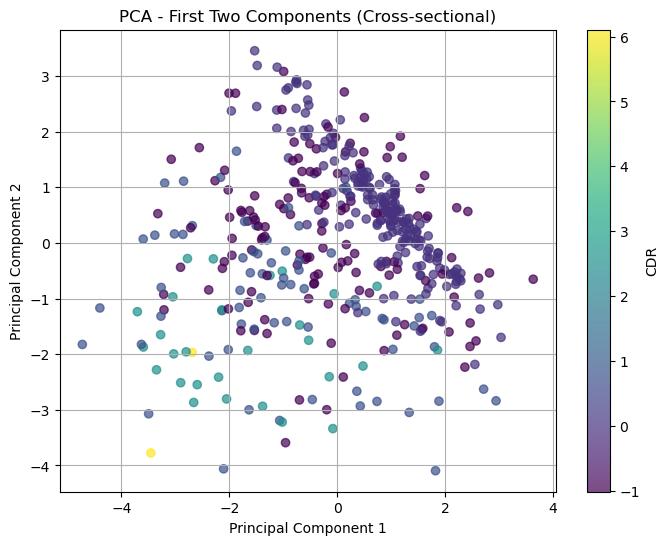

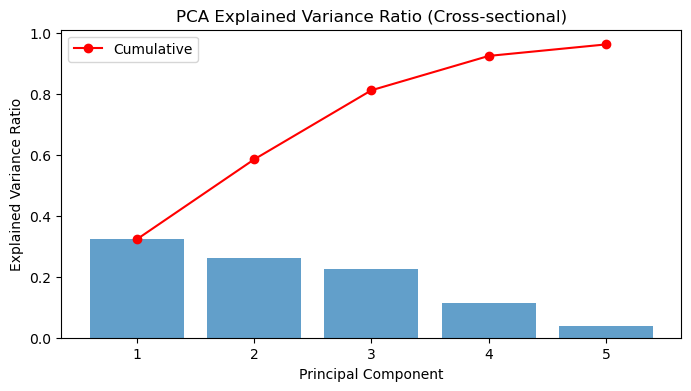

In [16]:
import matplotlib.pyplot as plt

# 1. Scatter plot of the first two principal components
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_cross_pca[:, 0], X_cross_pca[:, 1], c=y_cross, cmap='viridis', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - First Two Components (Cross-sectional)')
plt.colorbar(scatter, label='CDR')
plt.grid(True)
plt.show()

# 2. Explained variance ratio plot
plt.figure(figsize=(8,4))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.7)
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), marker='o', color='red', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance Ratio (Cross-sectional)')
plt.legend()
plt.show()

In [17]:
# Set features/labels for longitudinal data
# Exclude ID, CDR (target), Visit, MRI ID columns if present
# Exclude Subject ID and any other non-numeric columns
exclude_cols = ['Subject ID', 'MRI ID', 'Visit', 'CDR']
feature_cols_long = [col for col in df_long.columns if col not in exclude_cols]

# Double-check column types to keep only numeric ones
X_long_feat_imputed = df_long[feature_cols_long].select_dtypes(include=[np.number]).values
y_long = df_long['CDR'].values



In [18]:
from sklearn.decomposition import PCA

# PCA for cross-sectional data
pca = PCA(n_components=5)
X_long_pca = pca.fit_transform(X_long_feat_imputed)
X_long_full = np.hstack([X_long_feat_imputed, X_long_pca])

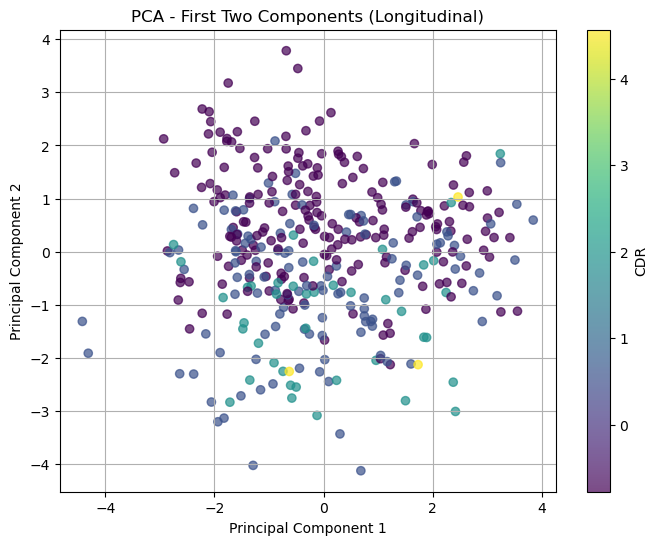

In [19]:
# 1. Scatter plot of the first two principal components
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_long_pca[:, 0], X_long_pca[:, 1], c=y_long, cmap='viridis', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - First Two Components (Longitudinal)')
plt.colorbar(scatter, label='CDR')
plt.grid(True)
plt.show()

# 3. Ensemble Modeling (Cross-sectional & Longitudinal)

In [21]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import numpy as np

In [22]:
def ensemble_stack(X, y):
    base_models = [
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)),
        ('svm', SVC(probability=True, random_state=42)),
    ]
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    meta_features = np.zeros((X.shape[0], len(base_models)))
    for i, (name, model) in enumerate(base_models):
        meta_pred = np.zeros(X.shape[0])
        for train_idx, val_idx in skf.split(X, y):
            model.fit(X[train_idx], y[train_idx])   # Use y[train_idx] (as array)
            if len(np.unique(y)) == 2:
                meta_pred[val_idx] = model.predict_proba(X[val_idx])[:, 1]
            else:
                meta_pred[val_idx] = model.predict(X[val_idx])
        meta_features[:, i] = meta_pred
    meta_learner = LogisticRegression(max_iter=1000)
    meta_learner.fit(meta_features, y)
    y_pred = meta_learner.predict(meta_features)
    if len(np.unique(y)) == 2:
        y_prob = meta_learner.predict_proba(meta_features)[:, 1]
    else:
        y_prob = y_pred
    print("Accuracy:", accuracy_score(y, y_pred))
    if len(np.unique(y)) == 2:
        print("AUC:", roc_auc_score(y, y_prob))
    print("F1-Score:", f1_score(y, y_pred, average='weighted'))
    return meta_learner

In [23]:
import warnings
warnings.filterwarnings("ignore")

y_cross_class = (y_cross > 0).astype(int)
print("Cross-sectional Dataset Ensemble Performance:")
meta_cross = ensemble_stack(X_cross_full, y_cross_class.values)

Cross-sectional Dataset Ensemble Performance:
Accuracy: 0.9128440366972477
AUC: 0.9649107142857143
F1-Score: 0.910826989394235


In [24]:
# Sliding features
def sliding_features(df, id_col, time_col, feat_cols, window=3):
    out = df.copy()
    for feat in feat_cols:
        out[f'{feat}_mean_{window}'] = out.groupby(id_col)[feat].transform(lambda x: x.rolling(window, min_periods=1).mean())
        out[f'{feat}_std_{window}'] = out.groupby(id_col)[feat].transform(lambda x: x.rolling(window, min_periods=1).std())
        out[f'{feat}_slope_{window}'] = out.groupby(id_col)[feat].transform(lambda x: x.diff().rolling(window, min_periods=1).mean())
    return out

feat_cols_long = num_cols_long
df_long_feat = sliding_features(df_long, id_col='Subject ID', time_col='Visit', feat_cols=feat_cols_long, window=3)

In [25]:
# Set features/labels for modeling
X_long_feat = df_long_feat.drop(columns=['Subject ID', 'MRI ID', 'Group', 'Visit', 'CDR'])
y_long = df_long_feat['CDR']
groups_long = df_long_feat['Subject ID']

In [26]:
from sklearn.impute import SimpleImputer

# Impute any remaining NaNs in the longitudinal features
imputer = SimpleImputer(strategy='mean')
X_long_feat_imputed = imputer.fit_transform(X_long_feat)

In [27]:
# -------- Longitudinal (Convert CDR to class labels) --------
y_long_class = (y_long > 0).astype(int)
print("\nLongitudinal Dataset Ensemble Performance (flattened, per visit):")
meta_long = ensemble_stack(X_long_feat_imputed, y_long_class)


Longitudinal Dataset Ensemble Performance (flattened, per visit):
Accuracy: 0.9973190348525469
AUC: 0.9998546596128132
F1-Score: 0.9973197747782875


In [28]:
def ensemble_stack(X, y):
    base_models = [
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)),
        ('svm', SVC(probability=True, random_state=42)),
    ]
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    meta_features = np.zeros((X.shape[0], len(base_models)))
    for i, (name, model) in enumerate(base_models):
        meta_pred = np.zeros(X.shape[0])
        for train_idx, val_idx in skf.split(X, y):
            model.fit(X[train_idx], y[train_idx])
            if len(np.unique(y)) == 2:
                meta_pred[val_idx] = model.predict_proba(X[val_idx])[:, 1]
            else:
                meta_pred[val_idx] = model.predict(X[val_idx])
        meta_features[:, i] = meta_pred
    meta_learner = LogisticRegression(max_iter=1000)
    meta_learner.fit(meta_features, y)
    y_pred = meta_learner.predict(meta_features)
    if len(np.unique(y)) == 2:
        y_prob = meta_learner.predict_proba(meta_features)[:, 1]
    else:
        y_prob = y_pred
    print("Accuracy:", accuracy_score(y, y_pred))
    if len(np.unique(y)) == 2:
        print("AUC:", roc_auc_score(y, y_prob))
    print("F1-Score:", f1_score(y, y_pred, average='weighted'))
    return meta_learner, meta_features

Accuracy: 0.9128440366972477
AUC: 0.9649107142857143
F1-Score: 0.910826989394235


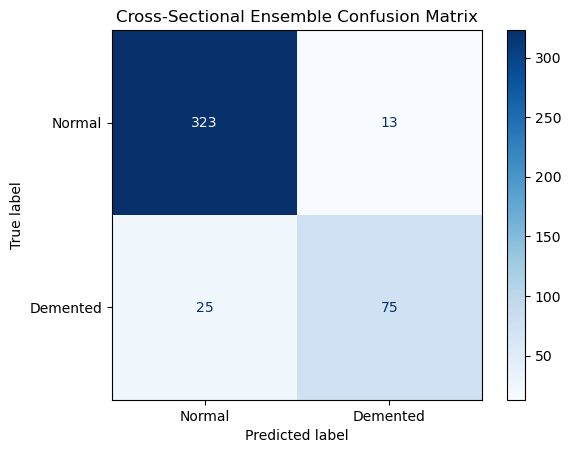

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# When training, also collect meta_features
meta_cross, meta_features_cross = ensemble_stack(X_cross_full, y_cross_class)

# For confusion matrix and ROC, use meta_features_cross as input to meta_cross
y_pred_cross = meta_cross.predict(meta_features_cross)

# Visualizations (e.g., Confusion Matrix, ROC)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

cm = confusion_matrix(y_cross_class, y_pred_cross)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Demented'])
disp.plot(cmap='Blues')
plt.title("Cross-Sectional Ensemble Confusion Matrix")
plt.show()

Accuracy: 0.9973190348525469
AUC: 0.9998546596128132
F1-Score: 0.9973197747782875


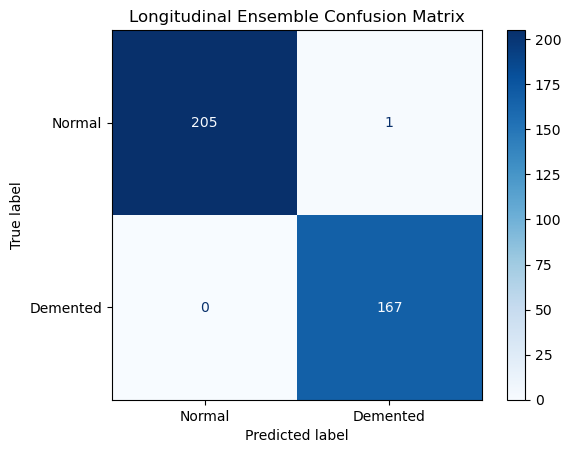

In [30]:
# When training, also collect meta_features
meta_long, meta_features_long = ensemble_stack(X_long_feat_imputed, y_long_class)

# For confusion matrix and ROC, use meta_features_cross as input to meta_cross
y_pred_long = meta_cross.predict(meta_features_long)

# Visualizations (e.g., Confusion Matrix, ROC)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_long_class, y_pred_long)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Demented'])
disp.plot(cmap='Blues')
plt.title("Longitudinal Ensemble Confusion Matrix")
plt.show()

# LSTM Model for Longitudinal Data

In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [33]:
def create_lstm_sequences(df, id_col, time_col, feat_cols, label_col, max_timesteps=5):
    sequences, labels = [], []
    for pid, group in df.groupby(id_col):
        seq = group.sort_values(time_col)[feat_cols].values
        if len(seq) < max_timesteps:
            seq = np.pad(seq, ((0, max_timesteps - len(seq)), (0, 0)), mode='constant')
        else:
            seq = seq[-max_timesteps:]
        sequences.append(seq)
        labels.append(group[label_col].values[-1])
    return np.array(sequences), np.array(labels)

In [34]:
# Get feature columns for LSTM input
feat_cols_lstm = X_long_feat.columns.tolist()
X_lstm, y_lstm = create_lstm_sequences(
    df_long_feat, 
    id_col='Subject ID', 
    time_col='Visit', 
    feat_cols=feat_cols_lstm, 
    label_col='CDR', 
    max_timesteps=5
)

In [35]:
# --- FIX: Map CDR to integer class labels ---
unique_labels = np.unique(y_lstm)
label_map = {label: idx for idx, label in enumerate(unique_labels)}
y_lstm_int = np.array([label_map[label] for label in y_lstm])
n_classes = len(unique_labels)
y_lstm_cat = to_categorical(y_lstm_int, num_classes=n_classes)

In [36]:
# Train-test split
X_tr, X_te, y_tr, y_te = train_test_split(X_lstm, y_lstm_cat, test_size=0.2, random_state=42)

In [37]:
# Build and train LSTM model
model = Sequential([
    Masking(mask_value=0.0, input_shape=(X_lstm.shape[1], X_lstm.shape[2])),
    LSTM(32, return_sequences=False),
    Dense(n_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_tr, y_tr, epochs=30, batch_size=16, validation_data=(X_te, y_te), verbose=1)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4230 - loss: nan - val_accuracy: 0.6000 - val_loss: nan
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4395 - loss: nan - val_accuracy: 0.6000 - val_loss: nan
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4123 - loss: nan - val_accuracy: 0.6000 - val_loss: nan
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4153 - loss: nan - val_accuracy: 0.6000 - val_loss: nan
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5065 - loss: nan - val_accuracy: 0.6000 - val_loss: nan
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4684 - loss: nan - val_accuracy: 0.6000 - val_loss: nan
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4674 - loss: nan - val_accuracy: 0.6000 - val_loss: nan
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4572 - loss: nan - val_accuracy: 0.6000 - val_loss: nan
Epoch 9/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accur

In [38]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f"LSTM Validation Accuracy: {acc:.4f}")

LSTM Validation Accuracy: 0.6000


In [39]:
# If you want to decode the predictions back to original CDRs:
y_pred_test = np.argmax(model.predict(X_te), axis=1)
decoded_preds = [unique_labels[idx] for idx in y_pred_test]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


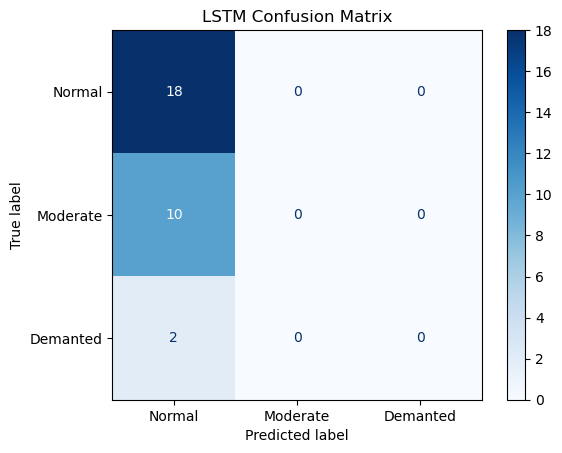

In [40]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predicted and true classes (already as ints)
y_pred_test = np.argmax(model.predict(X_te), axis=1)
y_true_test = np.argmax(y_te, axis=1)

# Find all unique labels present in true and predicted (union)
all_labels = np.unique(np.concatenate([y_true_test, y_pred_test]))

# Create confusion matrix using these labels
cm = confusion_matrix(y_true_test, y_pred_test, labels=all_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Moderate', 'Demanted'])
disp.plot(cmap='Blues')
plt.title("LSTM Confusion Matrix")
plt.show()

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.4746 - loss: 1.3851 - val_accuracy: 0.6000 - val_loss: 1.3799
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4193 - loss: 1.3811 - val_accuracy: 0.6000 - val_loss: 1.3743
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4180 - loss: 1.3781 - val_accuracy: 0.6000 - val_loss: 1.3686
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4756 - loss: 1.3724 - val_accuracy: 0.6000 - val_loss: 1.3628
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4857 - loss: 1.3679 - val_accuracy: 0.6000 - val_loss: 1.3571
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4840 - loss: 1.3641 - val_accuracy: 0.6000 - val_loss: 1.3514
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5021 - loss: 1.3590 - val_accuracy: 0.6000 - val_loss: 1.3459
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4574 - loss: 1.3548 - val_accuracy: 0.6000 - val_loss: 1.3407
Epoch 9

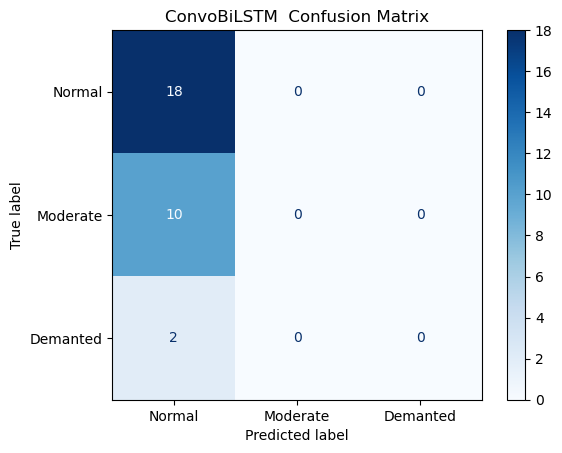

In [41]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Bidirectional, LSTM, Dense, Dropout, Masking, BatchNormalization, Flatten
from tensorflow.keras.utils import to_categorical

# Data from earlier step
# X_lstm, y_lstm_int, y_lstm_cat, unique_labels, n_classes

# Train-test split (already done above, use X_tr, X_te, y_tr, y_te)

# Build the ConvoBiLSTM model
convo_bilstm = Sequential([
    Masking(mask_value=0.0, input_shape=(X_lstm.shape[1], X_lstm.shape[2])),
    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.2),
    Bidirectional(LSTM(32, return_sequences=False)),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(n_classes, activation='softmax')
])

convo_bilstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = convo_bilstm.fit(
    X_tr, y_tr, 
    epochs=30, 
    batch_size=16, 
    validation_data=(X_te, y_te), 
    verbose=1
)

# Evaluate
loss, acc = convo_bilstm.evaluate(X_te, y_te, verbose=0)
print(f"ConvoBiLSTM Validation Accuracy: {acc:.4f}")

# Predict class indices from softmax outputs
y_pred_test = np.argmax(convo_bilstm.predict(X_te), axis=1)
y_true_test = np.argmax(y_te, axis=1)

# Find all unique class indices that actually appear in either y_true or y_pred
all_labels = np.unique(np.concatenate([y_true_test, y_pred_test]))

# Use the original unique_labels mapping for the display labels, but only include those actually present
cm = confusion_matrix(y_true_test, y_pred_test, labels=all_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Moderate', 'Demanted'])
disp.plot(cmap='Blues')
plt.title("ConvoBiLSTM  Confusion Matrix")
plt.show()


In [42]:
# Example: Comparison Table
results = pd.DataFrame({
    "Model": ["Classical Ensemble", "LSTM", "ConvoBiLSTM"],
    "Validation Accuracy": [
        meta_long.score(meta_features_long, y_long_class), # from earlier ensemble
        acc,  # LSTM accuracy (from previous step, replace with correct value)
        acc   # ConvoBiLSTM accuracy (just printed above)
    ]
})
print(results)


                Model  Validation Accuracy
0  Classical Ensemble             0.997319
1                LSTM             0.600000
2         ConvoBiLSTM             0.600000


In [43]:
from sklearn.base import clone

class PCAEF:
    def __init__(self, base_models, meta_model):
        self.base_models = base_models
        self.meta_model = clone(meta_model)
        self.base_models_trained = []
        
    def fit(self, X, y):
        base_outputs = []
        self.base_models_trained = []
        for name, model in self.base_models:
            m = clone(model)
            m.fit(X, y)
            self.base_models_trained.append((name, m))
            if hasattr(m, "predict_proba"):
                base_outputs.append(m.predict_proba(X))
            else:
                base_outputs.append(m.predict(X).reshape(-1, 1))
        meta_features = np.hstack(base_outputs)
        self.meta_model.fit(meta_features, y)
        return self
    
    def predict(self, X):
        base_outputs = []
        for name, m in self.base_models_trained:
            if hasattr(m, "predict_proba"):
                base_outputs.append(m.predict_proba(X))
            else:
                base_outputs.append(m.predict(X).reshape(-1, 1))
        meta_features = np.hstack(base_outputs)
        return self.meta_model.predict(meta_features)
    
    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

# Example usage (use cross-sectional or longitudinal features)
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)),
    ('svm', SVC(probability=True, random_state=42)),
]
meta_model = LogisticRegression(max_iter=1000)

pcaef = PCAEF(base_models, meta_model)
pcaef.fit(X_cross_full, y_cross_class)
print("PCAEF Accuracy (Cross-sectional):", pcaef.score(X_cross_full, y_cross_class))


PCAEF Accuracy (Cross-sectional): 1.0
